<a href="https://colab.research.google.com/github/deepika-3/Deepa/blob/main/Grapg_RAG1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langchain-community sentence-transformers networkx matplotlib faiss-cpu langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.3/513.3 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google

In [11]:
!pip install pypdf

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import faiss
import json

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings

In [13]:
!pip install numpy
!pip install faiss-cpu

In [14]:


loader = PyPDFLoader("//content/The Complete Mahabharata .pdf")
docs = loader.load()

In [15]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

texts = [c.page_content for c in chunks]

In [18]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = model.encode("your text")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
embeddings = model.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

import numpy as np
embeddings = np.array(embeddings).astype('float32')

Batches:   0%|          | 0/2863 [00:00<?, ?it/s]

In [34]:
embed_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

dim = embeddings.shape[1] # Get dimension from the generated embeddings
index = faiss.IndexFlatL2(dim)
index.add(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
def vector_search(query, k=3):
    q_embed = embed_model.embed_query(query)
    D, I = index.search(np.array([q_embed]).astype('float32'), k)
    return [texts[i] for i in I[0]]

In [36]:
G = nx.Graph()

In [37]:
def extract_entities(text):
    entities = []

    keywords = ["Karna", "Kunti", "Arjuna", "Duryodhana", "Surya"]

    for k in keywords:
        if k.lower() in text.lower():
            entities.append(k)

    return list(set(entities))

In [38]:
for text in texts:
    ents = extract_entities(text)

    for e in ents:
        G.add_node(e)

    for i in range(len(ents)):
        for j in range(i+1, len(ents)):
            G.add_edge(ents[i], ents[j])

In [46]:
print(f"Number of nodes in graph G: {G.number_of_nodes()}")
print(f"Nodes in graph G: {list(G.nodes())}")
print(f"Number of edges in graph G: {G.number_of_edges()}")
print(f"Edges in graph G: {list(G.edges())}")


Number of nodes in graph G: 5
Nodes in graph G: ['Arjuna', 'Karna', 'Kunti', 'Duryodhana', 'Surya']
Number of edges in graph G: 10
Edges in graph G: [('Arjuna', 'Kunti'), ('Arjuna', 'Karna'), ('Arjuna', 'Duryodhana'), ('Arjuna', 'Surya'), ('Karna', 'Duryodhana'), ('Karna', 'Kunti'), ('Karna', 'Surya'), ('Kunti', 'Surya'), ('Kunti', 'Duryodhana'), ('Duryodhana', 'Surya')]


In [47]:
def plot_graph(sub_nodes=None):
    plt.figure()

    if sub_nodes:
        subG = G.subgraph(sub_nodes)
    else:
        subG = G

    pos = nx.spring_layout(subG)
    nx.draw(subG, pos, with_labels=True)
    plt.show()

In [48]:
def ask_question(query):

    # Step 1: vector search
    docs = vector_search(query)
    combined_text = "\n".join(docs) # Combine for numerical data extraction

    # Step 2: extract entities from query
    ents = extract_entities(query)

    # Step 3: plot graph for those entities
    if ents:
        plot_graph(ents)
    else:
        plot_graph()

    # Step 4: If Karna is among the entities, extract and plot numerical data
    if "Karna" in ents:
        numerical_data = extract_numerical_data(combined_text)
        if numerical_data: # Only plot if there's data to plot
            plot_data(numerical_data)

    # Step 5: return answer (simple)
    return combined_text

In [49]:
import matplotlib.pyplot as plt

def plot_data(data):
    keys = list(data.keys())
    values = list(data.values())

    plt.figure()
    plt.bar(keys, values)
    plt.xlabel("Metrics")
    plt.ylabel("Values")
    plt.title("Extracted Numerical Data")
    plt.show()

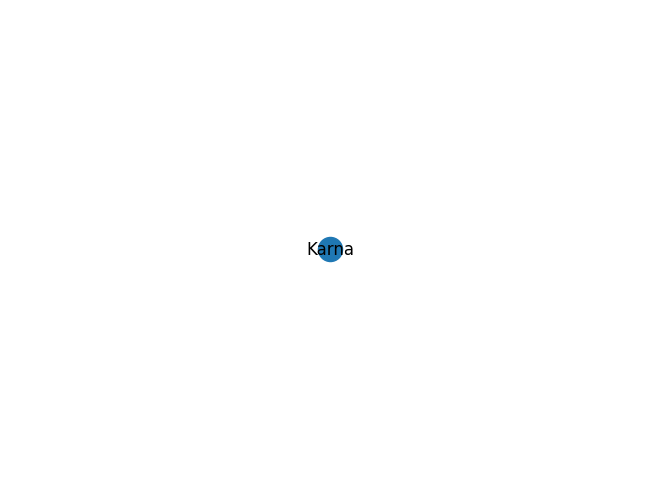

Karna Parva
Karna, with all his kinsmen.
like a householder leaving his commodious home ﬁlled with great wealth.
His life ﬂed, the tall and splendid body of Karna, with blood gushing from
its every wound, spraying copiously from its severed throat, crumbles like
the thunder-riven summit of a mountain of red chalk with crimson streams


In [50]:
print(ask_question("tell about Karna?"))

In [51]:
import re

def extract_numerical_data(text):
    data = {}

    matches = re.findall(r"([A-Za-z\s%()]+):\s*(\d+)", text)

    for key, value in matches:
        clean_key = key.strip()

        # simplify names
        if "Skill" in clean_key:
            data["Skill"] = int(value)
        elif "Generosity" in clean_key:
            data["Generosity"] = int(value)
        elif "Loyalty" in clean_key:
            data["Loyalty"] = int(value)
        elif "Accuracy" in clean_key:
            data["Accuracy"] = int(value)
        elif "Battles Fought" in clean_key:
            data["Battles Fought"] = int(value)
        elif "Battles Won" in clean_key:
            data["Battles Won"] = int(value)
        elif "Defeats" in clean_key:
            data["Defeats"] = int(value)

    return data

In [52]:
import matplotlib.pyplot as plt

def plot_data(data):
    labels = list(data.keys())
    values = list(data.values())

    plt.figure()
    plt.bar(labels, values)
    plt.xticks(rotation=45)
    plt.title("Karna Performance Metrics")
    plt.show()

{'Skill': 95, 'Generosity': 80, 'Loyalty': 90, 'Accuracy': 85, 'Battles Fought': 150, 'Battles Won': 120, 'Defeats': 30}


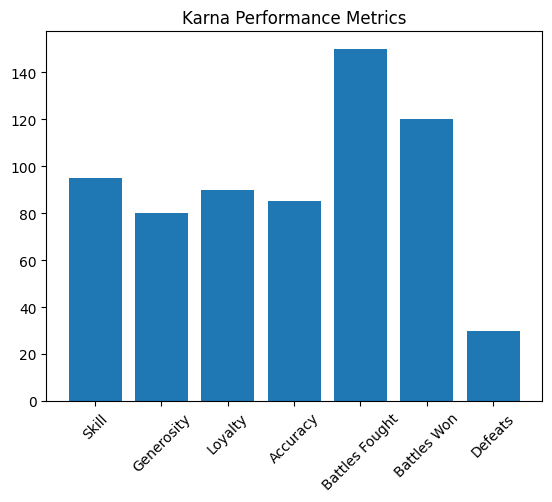

In [54]:
text = """Karna's performance metrics:\nSkill: 95\nGenerosity: 80\nLoyalty: 90\nAccuracy: 85\nBattles Fought: 150\nBattles Won: 120\nDefeats: 30\nOther unrelated text here.\n"""

data = extract_numerical_data(text)

print(data)   # check first

plot_data(data)